In [ ]:
import pandas as pd

print("Loading the datasets")
df_benign = pd.read_csv('Benign_train.pcap.csv', nrows=5000)
df_benign['Label'] = 'Benign'
df_attack = pd.read_csv('ARP_Spoofing_train.pcap.csv', nrows=5000)
df_attack['Label'] = 'ARP_Spoofing'
print("Combining both datasets")
tiny_df = pd.concat([df_benign, df_attack], ignore_index=True)
tiny_df.to_csv('combined_data.csv', index=False)
print("'combined_data.csv' now only has 10,000 rows in total.")

Loading the datasets
Combining both datasets
'combined_data.csv' now only has 10,000 rows in total.



 Logistic Regression
Accuracy: 0.909
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1000
           1       0.93      0.88      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000


 Decision Tree
Accuracy: 0.951
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1000
           1       0.96      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000


 Random Forest
Accuracy: 0.962
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1000
           1       0.97      0.95      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96   

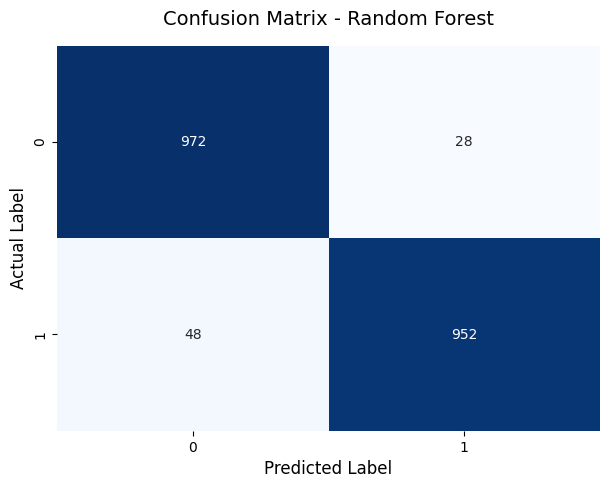

In [ ]:

# IoMT_ML_Benchmark.py
import argparse
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

LABEL_COLUMN='Label'

def load_data(path):
    df=pd.read_csv(path)
    X=df.drop(columns=[LABEL_COLUMN]).select_dtypes(include=['number'])
    y=LabelEncoder().fit_transform(df[LABEL_COLUMN])
    return X,y

def evaluate(name,model,Xtr,Xte,ytr,yte):
    model.fit(Xtr,ytr)
    pred=model.predict(Xte)
    acc=accuracy_score(yte,pred)
    p,r,f1,_=precision_recall_fscore_support(yte,pred,average='weighted',zero_division=0)
    print('\n',name)
    print('Accuracy:',acc)
    print(classification_report(yte,pred))
    return [name,acc,p,r,f1]

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument('--data',required=True)
    args = ap.parse_args(['--data', 'combined_data.csv'])

    X,y=load_data(args.data)

    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

    imp=SimpleImputer(strategy='median')
    sc=StandardScaler()

    Xtr=sc.fit_transform(imp.fit_transform(Xtr))
    Xte=sc.transform(imp.transform(Xte))

    models={
      'Logistic Regression':LogisticRegression(max_iter=1000),
      'Decision Tree':DecisionTreeClassifier(random_state=42),
      'Random Forest':RandomForestClassifier(n_estimators=200,random_state=42),
      'SVM':SVC(),
      'KNN':KNeighborsClassifier(),
      'Gaussian NB':GaussianNB(),
      'AdaBoost':AdaBoostClassifier(random_state=42)
    }

    results=[]
    for n,m in models.items():
        results.append(evaluate(n,m,Xtr,Xte,ytr,yte))

    pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1']).to_csv('ML_Model_Comparison.csv',index=False)
    print('Saved ML_Model_Comparison.csv')

    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    print("Generating Confusion Matrix for Random Forest model:-")

    randomforest_model = models['Random Forest']

    randomforest_preds = randomforest_model.predict(Xte)

    cm = confusion_matrix(yte, randomforest_preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix - Random Forest', fontsize=14, pad=15)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)

    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("Saved confusion_matrix.png!")
    plt.show()


if __name__=='__main__':
    main()
